### [TA-Lib in Python: The Gold Standard for Technical Analysis](https://medium.com/coding-nexus/ta-lib-in-python-the-gold-standard-for-technical-analysis-f7f16f577ca0)

> TA-Lib (Technical Analysis Library) - Why a 25-year-old C library still outperforms modern Python stacks for serious market analysis

**TA-Lib** is an open-source technical analysis library that implements over 150 financial indicators and 60+ candlestick pattern recognition functions. These include widely used tools such as RSI, MACD, Bollinger Bands, ATR, Stochastic Oscillators, and dozens of moving average variants. But the critical detail is not the indicator count.

In [1]:
!pip install --quiet TA-Lib yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 41.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import talib as ta
import yfinance as yf

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download data
data = yf.download("AAPL", period="2y", auto_adjust=False, progress=False)

# If yfinance returns MultiIndex columns, flatten them
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Convert to clean 1D float arrays for TA-Lib
close = data['Close'].to_numpy(dtype=float).ravel()
high = data['High'].to_numpy(dtype=float).ravel()
low = data['Low'].to_numpy(dtype=float).ravel()
open_ = data['Open'].to_numpy(dtype=float).ravel()
volume = data['Volume'].to_numpy(dtype=float).ravel()

display(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  502 non-null    float64
 1   Close      502 non-null    float64
 2   High       502 non-null    float64
 3   Low        502 non-null    float64
 4   Open       502 non-null    float64
 5   Volume     502 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 27.5 KB


None

In [4]:
display(data.sample(15))

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-10-03,257.770111,258.019989,259.239990,253.949997,254.669998,49155600
2025-04-09,198.172348,198.850006,200.610001,171.889999,171.949997,184395900
2024-09-05,221.135468,222.380005,225.479996,221.520004,221.630005,36615400
2025-11-17,267.459991,267.459991,270.489990,265.730011,268.820007,45018300
2025-08-01,201.954803,202.380005,213.580002,201.500000,210.869995,104434500
2025-04-28,209.423889,210.139999,211.500000,207.460007,210.000000,38743100
2025-02-03,226.983414,228.009995,231.830002,225.699997,229.990005,73063300
2024-04-16,168.009445,169.380005,173.759995,168.270004,171.750000,73711200
2024-09-20,226.922882,228.199997,233.089996,227.619995,229.970001,318679900


In [5]:
display(data.describe())

Price,Adj Close,Close,High,Low,Open,Volume
count,502.000000,502.000000,502.000000,502.000000,502.000000,5.020000e+02
mean,218.757740,219.673346,221.770937,217.372191,219.449103,5.564709e+07
std,29.140908,28.827568,28.916674,28.625622,28.792856,2.732572e+07
min,163.664902,165.000000,166.399994,164.080002,165.350006,1.791060e+07
25%,197.838493,198.442497,200.412495,195.332504,197.842503,4.132715e+07
50%,220.955261,222.105003,224.269997,219.705002,221.450005,4.890840e+07
75%,235.626846,236.644997,238.632500,233.717499,236.019993,6.041002e+07
max,286.190002,286.190002,288.619995,283.299988,286.200012,3.186799e+08


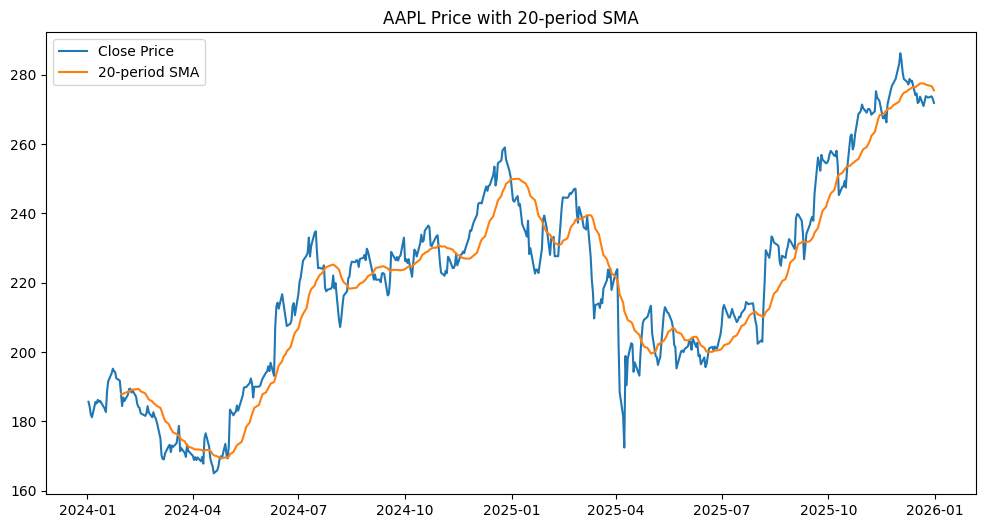

In [6]:
# Indicators
sma_20 = ta.SMA(close, timeperiod=20)
rsi_14 = ta.RSI(close, timeperiod=14)

plt.figure(figsize=(12, 6))
plt.plot(data.index, close, label='Close Price')
plt.plot(data.index, sma_20, label='20-period SMA')
plt.title('AAPL Price with 20-period SMA')
plt.legend()
plt.show()

#### MACD for Trend Confirmation

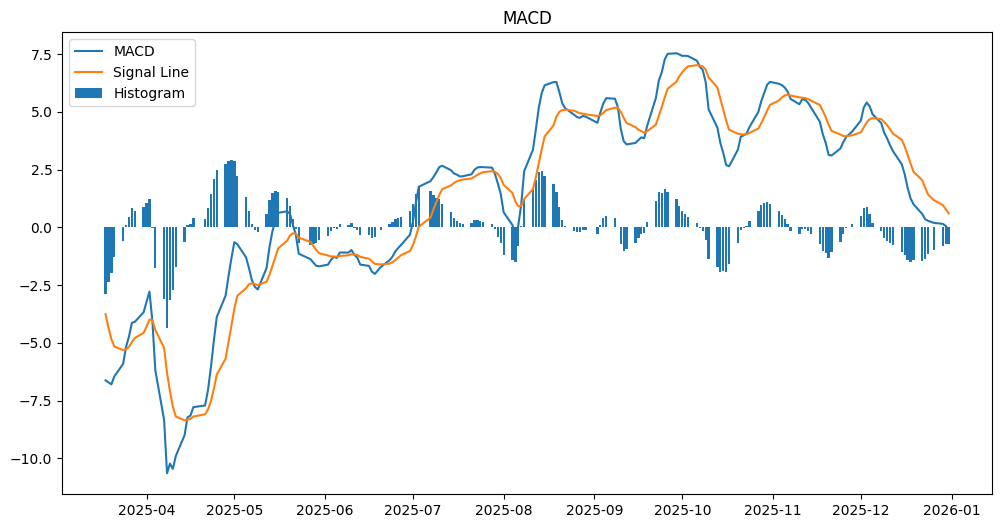

In [7]:
macd, macd_signal, macd_hist = ta.MACD(
    close,
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

plt.figure(figsize=(12, 6))
plt.plot(data.index[-200:], macd[-200:], label='MACD')
plt.plot(data.index[-200:], macd_signal[-200:], label='Signal Line')
plt.bar(data.index[-200:], macd_hist[-200:], label='Histogram')
plt.title('MACD')
plt.legend()
plt.show()

#### Bollinger Bands for Volatility Context

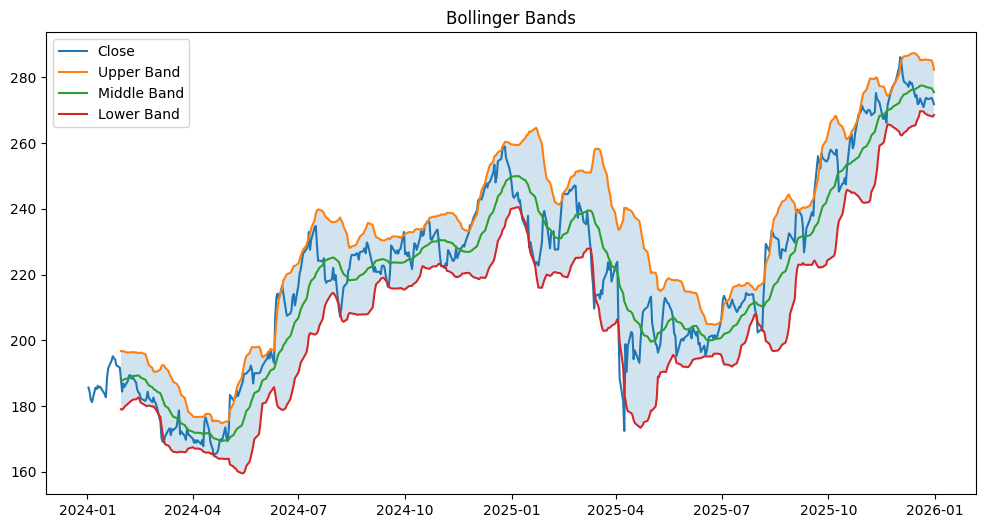

In [8]:
upper, middle, lower = ta.BBANDS(
    close,
    timeperiod=20,
    nbdevup=2,
    nbdevdn=2
)

plt.figure(figsize=(12, 6))
plt.plot(data.index, close, label='Close')
plt.plot(data.index, upper, label='Upper Band')
plt.plot(data.index, middle, label='Middle Band')
plt.plot(data.index, lower, label='Lower Band')
plt.fill_between(data.index, upper, lower, alpha=0.2)
plt.title('Bollinger Bands')
plt.legend()
plt.show()

#### Candlestick Pattern Detection

In [9]:
doji = ta.CDLDOJI(open_, high, low, close)

data['Doji'] = doji
doji_dates = data[data['Doji'] == 100].index
print("Doji patterns detected on:")
display(doji_dates)

Doji patterns detected on:


DatetimeIndex(['2024-01-23', '2024-02-09', '2024-02-15', '2024-02-20',
               '2024-03-01', '2024-03-07', '2024-03-11', '2024-03-12',
               '2024-03-14', '2024-03-25', '2024-03-26', '2024-03-28',
               '2024-04-02', '2024-04-05', '2024-04-22', '2024-04-29',
               '2024-05-08', '2024-05-14', '2024-06-24', '2024-06-25',
               '2024-07-16', '2024-07-30', '2024-08-08', '2024-08-15',
               '2024-08-19', '2024-08-21', '2024-08-29', '2024-09-09',
               '2024-09-12', '2024-09-16', '2024-09-26', '2024-10-15',
               '2024-10-16', '2024-10-28', '2024-11-06', '2024-11-08',
               '2024-11-12', '2024-12-04', '2024-12-06', '2024-12-13',
               '2024-12-30', '2025-01-03', '2025-02-18', '2025-02-19',
               '2025-02-21', '2025-03-05', '2025-03-17', '2025-03-20',
               '2025-03-24', '2025-04-15', '2025-04-17', '2025-04-21',
               '2025-04-28', '2025-05-06', '2025-05-08', '2025-05-09',
      